In [11]:
import pandas as pd
import os

data = r"C:\Users\itsma\Desktop\sepsiswatch\data\raw"

patient_all = []

for file in os.listdir(data):
    if file.endswith('.psv'):
        df = pd.read_csv(os.path.join(data,file), sep='|')
        df['patient_id']=file.replace('.psv','')
        patient_all.append(df)

final_data = pd.concat(patient_all, ignore_index = True)

print("Total rows:", len(final_data))
print("Total patients:" ,final_data['patient_id'].nunique())
print("\nColumns:",list(final_data.columns))


Total rows: 96082
Total patients: 2458

Columns: ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'SepsisLabel', 'patient_id']


In [12]:
print("Sepsis cases vs non-sepsis cases: ")
print(final_data['SepsisLabel'].value_counts())
print("\nMissing values per column: ")
print(final_data.isnull().sum())

Sepsis cases vs non-sepsis cases: 
SepsisLabel
0    93987
1     2095
Name: count, dtype: int64

Missing values per column: 
HR                   7818
O2Sat               11800
Temp                63086
SBP                 14613
MAP                 10076
DBP                 45679
Resp                10038
EtCO2               96082
BaseExcess          85476
HCO3                88257
FiO2                82308
pH                  84425
PaCO2               87204
SaO2                90925
AST                 94666
BUN                 88185
Alkalinephos        94697
Calcium             91401
Chloride            88010
Creatinine          89756
Bilirubin_direct    95921
Glucose             83935
Lactate             92543
Magnesium           88507
Phosphate           91297
Potassium           85349
Bilirubin_total     94947
TroponinI           95953
Hct                 84506
Hgb                 87433
PTT                 91332
WBC                 88820
Fibrinogen          95296
Platelets         

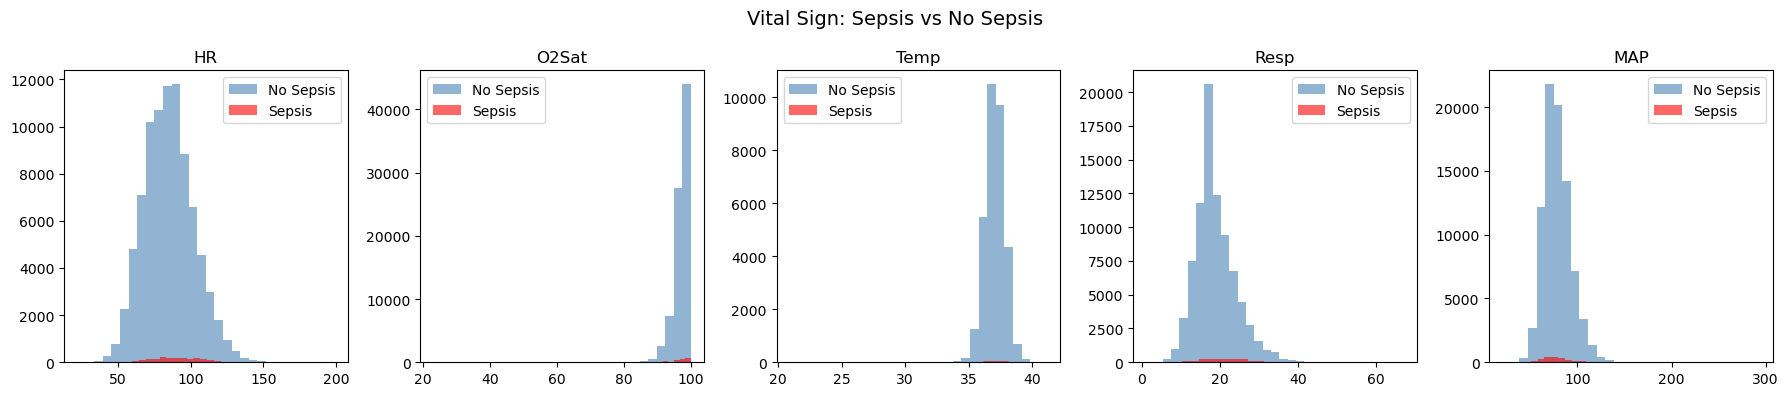

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
drop_cols = ['EtCO2','Bilirubin_direct','TroponinI','Fibrinogen','SaO2','Bilirubin_total']
data_clean = final_data.drop(columns = drop_cols)
sepsis = data_clean[data_clean['SepsisLabel'] == 1]
no_sepsis = data_clean[data_clean['SepsisLabel'] == 0]
vitals = ['HR','O2Sat','Temp','Resp','MAP']
fig,axes = plt.subplots(1,5,figsize=(18,4))
fig.suptitle('Vital Sign: Sepsis vs No Sepsis', fontsize = 14)
for i, vital in enumerate(vitals):
    axes[i].hist(no_sepsis[vital].dropna(),bins = 30, alpha = 0.6, label = 'No Sepsis', color = 'steelblue')
    axes[i].hist(sepsis[vital].dropna(),bins = 30, alpha = 0.6, label = 'Sepsis', color = 'red')
    axes[i].set_title(vital)
    axes[i].legend()
plt.tight_layout()
plt.show()

In [14]:
print("Sepsis patients - average vitals:")
print(sepsis[vitals].mean().round(2))

print("\nNon-sepsis patients - average vitals:")
print(no_sepsis[vitals].mean().round(2))

Sepsis patients - average vitals:
HR       91.31
O2Sat    96.89
Temp     37.23
Resp     20.78
MAP      77.24
dtype: float64

Non-sepsis patients - average vitals:
HR       85.07
O2Sat    97.25
Temp     37.04
Resp     18.75
MAP      78.50
dtype: float64


Patients who developed sepsis: 219


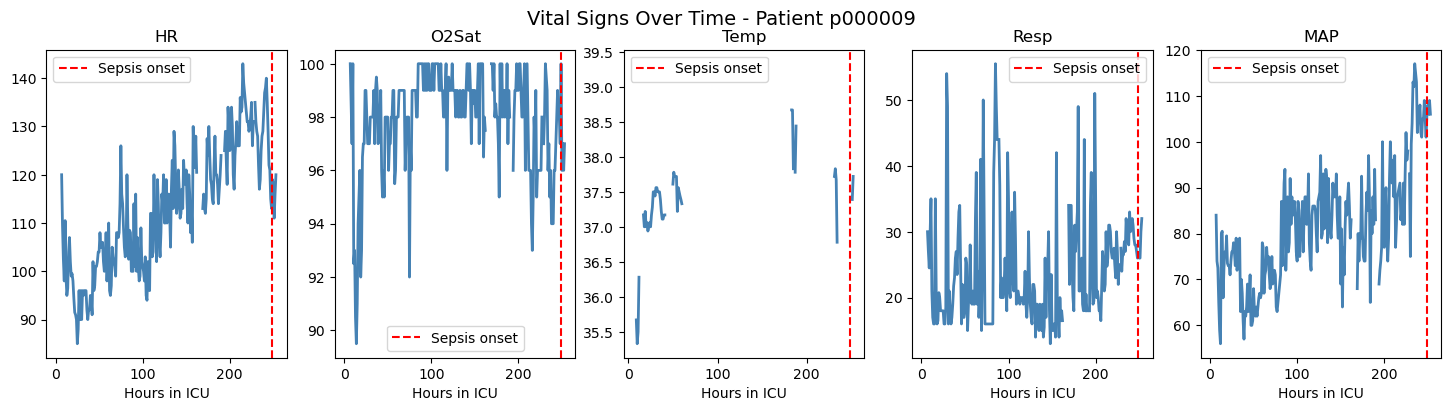

In [15]:
sepsis_pat = final_data[final_data['SepsisLabel'] == 1]['patient_id'].unique()
print(f"Patients who developed sepsis: {len(sepsis_pat)}")

example_pat = final_data[final_data['patient_id'] == sepsis_pat[0]]

fig, axes = plt.subplots(1, 5, figsize = (18, 4))
fig.suptitle(f'Vital Signs Over Time - Patient {sepsis_pat[0]}', fontsize = 14)

for i, vital in enumerate(vitals):
    axes[i].plot(example_pat['ICULOS'],
                 example_pat[vital],
                 color = 'steelblue', linewidth = 2)
    sepsis_start = example_pat[example_pat['SepsisLabel'] == 1]['ICULOS'].min()
    axes[i].axvline(x=sepsis_start, color = 'red', linestyle = '--', label = 'Sepsis onset')
    axes[i].set_title(vital)
    axes[i].set_xlabel('Hours in ICU')
    axes[i].legend()

plt.tight_layout
plt.show()

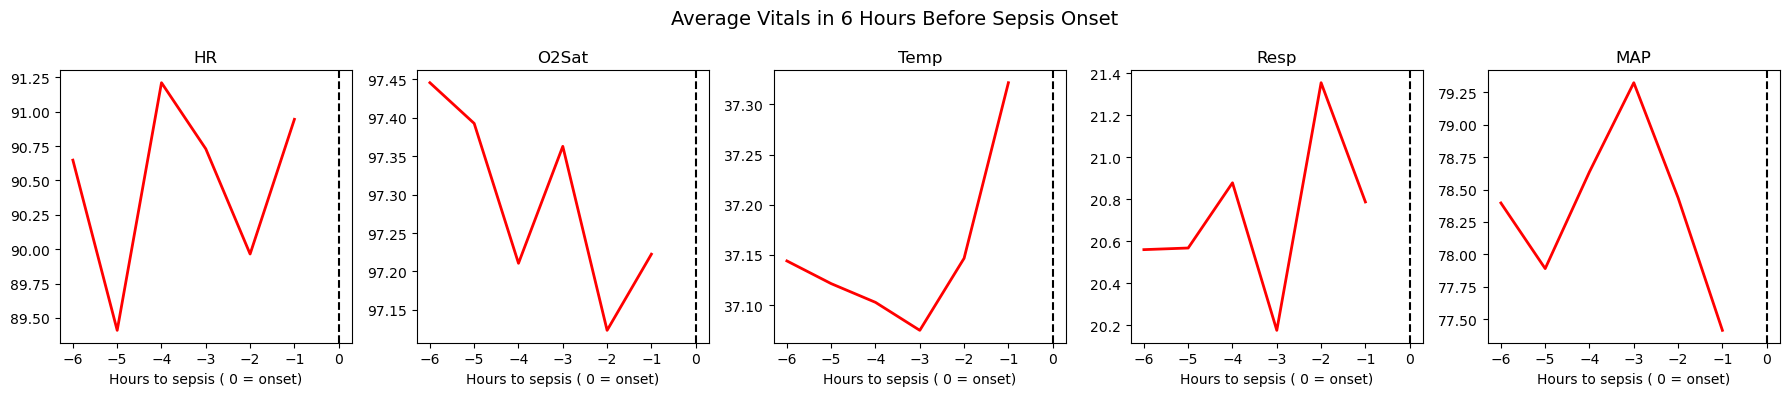

In [16]:
before_hours = 6

records = []

for pid in sepsis_pat:
    patient = final_data[final_data['patient_id'] == pid].copy()
    sepsis_hour = patient[patient['SepsisLabel'] == 1]['ICULOS'].min()

    pre_sepsis = patient[(patient['ICULOS'] >= sepsis_hour - before_hours) &
                         (patient['ICULOS'] < sepsis_hour)].copy()
    pre_sepsis['hours_to_sepsis'] = pre_sepsis['ICULOS'] - sepsis_hour
    records.append(pre_sepsis)

pre_sepsis_data = pd.concat(records, ignore_index=True)

fig, axes = plt.subplots(1, 5, figsize = (18,4))
fig.suptitle('Average Vitals in 6 Hours Before Sepsis Onset', fontsize = 14)

for i, vital in enumerate(vitals):
    avg = pre_sepsis_data.groupby('hours_to_sepsis')[vital].mean()
    axes[i].plot(avg.index, avg.values, color = 'red',linewidth =2)
    axes[i].set_title(vital)
    axes[i].set_xlabel('Hours to sepsis ( 0 = onset)')
    axes[i].axvline(x=0, color = 'black',linestyle = '--')

plt.tight_layout()
plt.show()